In [2]:
import pandas as pd

### 1. Data Loading and Project Architecture

Since the project is designed with a modular structure, all development notebooks are located within the `/notebooks` directory. A relative path (`../data/`) is utilized to access the raw dataset stored in the root `/data` folder.

In [3]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df['TotalCharges'].info()

<class 'pandas.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df = df.dropna(subset=['TotalCharges'])

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
columns = df.select_dtypes(include=['object', 'str']).columns
print(columns)
for c in columns:
    print(c)
    print(df[c].unique())
    print("-----------------------------------")

for c in columns:
    df[c] = df[c].str.strip()

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')
customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7032, dtype: str
-----------------------------------
gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
-----------------------------------
Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
-----------------------------------
Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
-----------------------------------
PhoneService
<StringArray>

In [13]:
pd.crosstab(df['InternetService'], df['OnlineBackup'])

OnlineBackup,No,No internet service,Yes
InternetService,,,
DSL,1334,0,1082
Fiber optic,1753,0,1343
No,0,1520,0


In [14]:
pd.crosstab(df['InternetService'], df['OnlineSecurity'])

OnlineSecurity,No,No internet service,Yes
InternetService,,,
DSL,1240,0,1176
Fiber optic,2257,0,839
No,0,1520,0


In [15]:
pd.crosstab(df['InternetService'], df['DeviceProtection'])

DeviceProtection,No,No internet service,Yes
InternetService,,,
DSL,1355,0,1061
Fiber optic,1739,0,1357
No,0,1520,0


#### Key Observation: Logical Dependency in Features
It is observed that for every customer where `InternetService` is labeled as `"No"`, all additional internet-related service columns (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) automatically default to `"No internet service"`. This indicates a strict logical dependency within the data structure.


### 2. Categorical Feature Simplification and Feature Redundancy Mitigation

The `"No internet service"` values across the supplementary service columns (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) have been downcasted to `"No"`. This decision is driven by their perfect correlation with the `InternetService` column, thereby eliminating redundant information across the dataset.

#### Engineering Rationale:

* **Mitigating the Curse of Dimensionality (Preventing Feature Explosion):** Standardizing these values prevents the creation of unnecessary dummy variables during the future One-Hot Encoding phase. This optimizes the model's input feature space, leading to reduced memory consumption and faster training times.
* **Addressing Multicollinearity:** Replicating the "no internet" sub-information across six different columns introduces high multicollinearity. This can destabilize parametric models (such as Logistic Regression and Neural Networks). Resolving this redundancy ensures mathematical stability.
* **Enhancing Model Generalization:** By streamlining the categorical responses, we optimize the splitting depth of tree-based models (e.g., XGBoost, Random Forest), preventing the algorithms from learning redundant rules (overfitting) and fostering a more parsimonious model architecture.

In [16]:
columns = df.select_dtypes(include=['object', 'str']).columns
target_cols = []
for c in columns:
    if 'No internet service' in df[c].values:
        print(c)
        target_cols.append(c)
print(target_cols)

OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [17]:
"""for c in target_cols:
    df[c] = df[c].replace('No internet service', 'No')"""

df[target_cols] = df[target_cols].replace('No internet service', 'No')

In [18]:
pd.crosstab(df['InternetService'], df['OnlineBackup'])

OnlineBackup,No,Yes
InternetService,,
DSL,1334,1082
Fiber optic,1753,1343
No,1520,0


In [19]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
df["Churn"].value_counts(normalize= True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

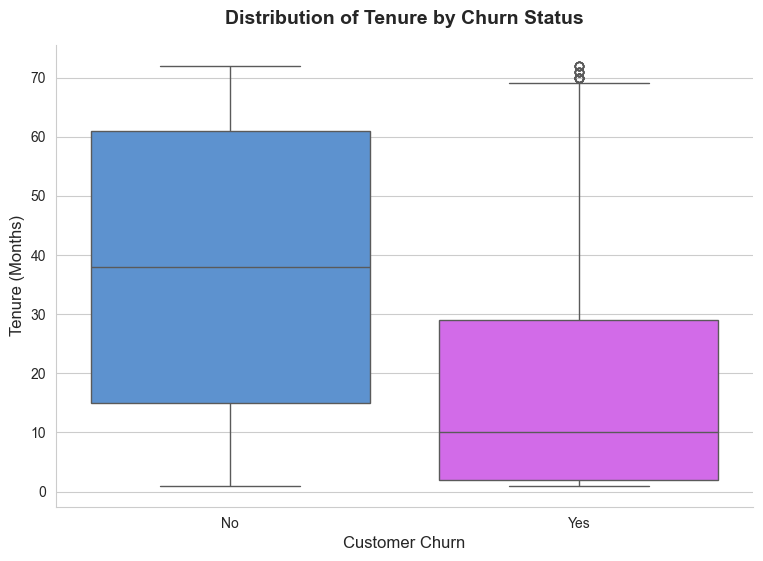

In [22]:
sns.set_style("whitegrid")
plt.figure(figsize=(9,6))
sns.boxplot(x="Churn",
            y="tenure",
            data=df,
            hue="Churn",
            palette=['#4a90e2', '#e056fd'],
            legend=False)
plt.title('Distribution of Tenure by Churn Status',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Churn', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)
sns.despine()
plt.show()

### 3. Exploratory Data Analysis (EDA) - Tenure vs. Churn Analysis

A bivariate analysis was conducted using a customized boxplot to understand the distribution of `tenure` (customer lifetime in months) across different `Churn` statuses.

#### Visual Insights & Business Interpretation:

* **Low Median Tenure for Churn Customers:** The median tenure for customers who churned ("Yes") is significantly low, hovering around **10 months**. This strongly indicates that the highest risk of customer defection occurs within the first year of subscription. Early-stage customer retention strategies are critical.
* **High Loyalty in Retained Customers:** Conversely, retained customers ("No") exhibit a much higher median tenure, located between **35 to 40 months**, showcasing a stable and loyal customer base once they pass the critical first-year threshold.
* **Presence of Outliers (Long-term Churn):** The upper whisker and individual data points on the "Yes" plot reveal several outliers—customers who stayed with the company for a very long duration (e.g., over 60 months) but eventually churned. These specific cases warrant a deeper look into potential late-stage triggers, such as sudden price hikes or unresolved technical issues.

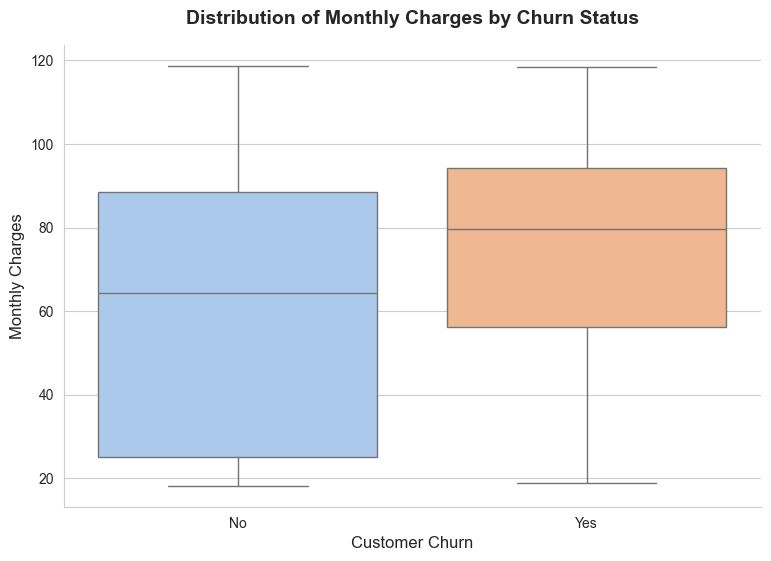

In [23]:
sns.set_style("whitegrid")
plt.figure(figsize=(9,6))
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df,
    hue="Churn",
    palette="pastel",
    legend=False
)
plt.title('Distribution of Monthly Charges by Churn Status',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Churn', fontsize=12)
plt.ylabel('Monthly Charges', fontsize=12)
sns.despine()
plt.show()

### 4. Exploratory Data Analysis (EDA) - Monthly Charges vs. Churn

An optimized boxplot analysis was conducted to evaluate the financial impact of monthly fees on customer defection.

### Visual Insights and Business Interpretation
The median monthly charge for churned customers is substantially higher, around $80, compared to retained customers whose median sits around $65. The core spending bracket for the churn group is tightly packed between $60 and $90. This confirms that customer loss is heavily concentrated among high-spending users.

### Price Sensitivity and Competitor Pressure
This distinct pattern reveals a critical vulnerability, showing that the company is systematically losing its highest-paying, premium customer segment. This attrition signals strong competitor pressure, aggressive poaching, or a potential failure within the company to properly demonstrate the value of premium services to these accounts.

### Strategic Action Item
Instead of generic retention campaigns, the marketing team should design targeted tier-retention programs. This includes exclusive loyalty rewards, custom plan downgrades, or high-tier discounts, specifically aimed at accounts paying above $70 per month to effectively mitigate high-value revenue leakage.
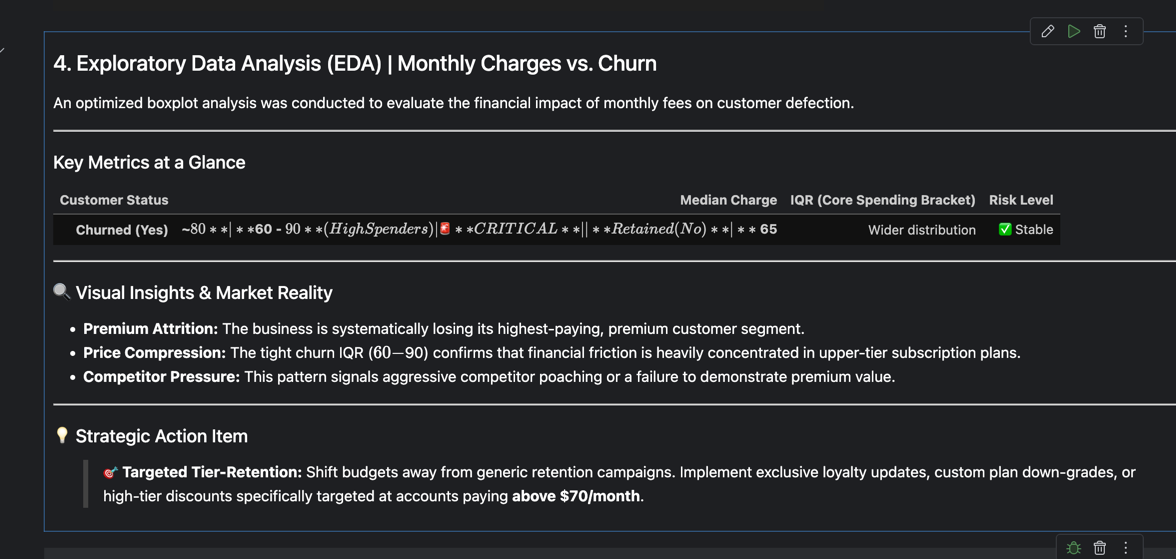

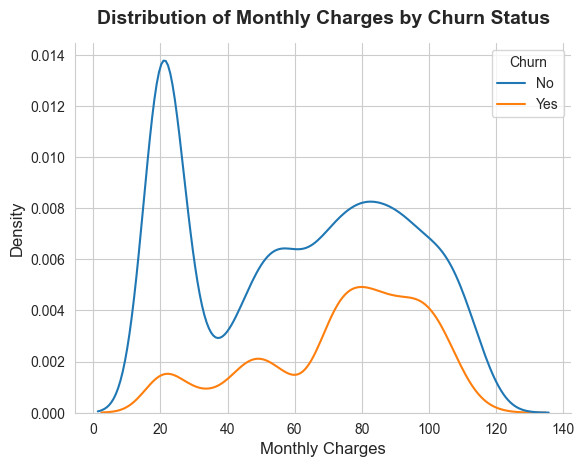

In [24]:
sns.kdeplot(x= 'MonthlyCharges', hue="Churn", data=df)
plt.title('Distribution of Monthly Charges by Churn Status',
          fontsize=14, fontweight='bold', pad=14)
plt.ylabel('Density', fontsize=12)
plt.xlabel('Monthly Charges', fontsize=12)
sns.despine()
plt.show()

### 5. Exploratory Data Analysis (EDA) - Probability Density of Monthly Charges

A Kernel Density Estimate (KDE) plot was implemented to visualize the continuous probability distribution of MonthlyCharges segmented by customer Churn status.

### The Low-Value Safe Zone around $20

A massive density spike for retained customers is observed around the $20 price point, whereas the churn curve remains nearly flat. This indicates that low-tier, basic-plan subscribers exhibit exceptionally low churn elasticity and present almost no risk to the business.

### The High-Value Danger Zone between $70  and  $110

Between $70 and $110, the probability density for churned customers reaches its absolute peak. This confirms our boxplot findings with even higher fidelity, proving that premium, high-revenue-generating accounts represent the highest operational risk for the organization.

### Bimodal Distribution of Loyalty

The retained group shows a clear bimodal distribution with two distinct peaks at $20 and $80. This proves that the company successfully retains a portion of premium users, but the high overlap with the churn peak highlights a highly volatile and sensitive high-tier market segment.

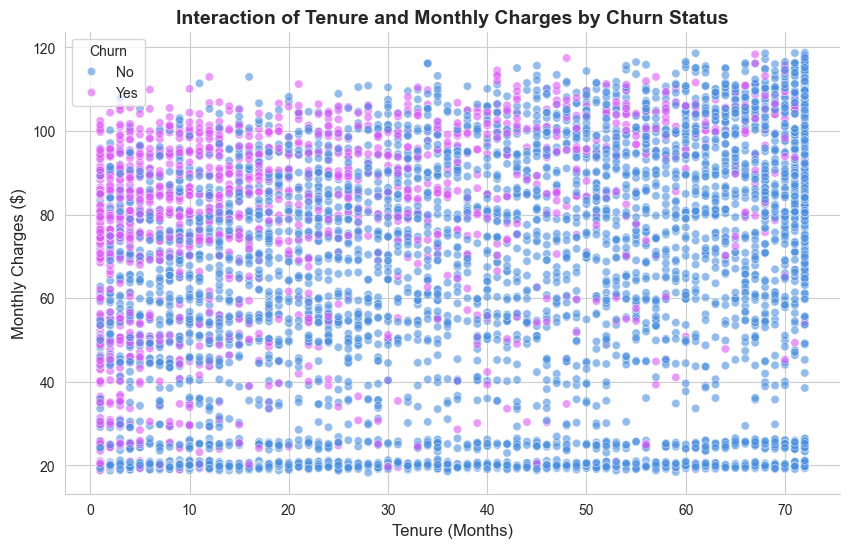

In [25]:
plt.figure(figsize=(10, 6))

# İki sayısal değişkeni Churn rengine göre çarpıştır
sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    data=df,
    palette=['#4a90e2', '#e056fd'],
    alpha=0.6  # Noktaların şeffaflığı (overplotting'i önlemek için)
)

plt.title('Interaction of Tenure and Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
sns.despine()
plt.show()

In [26]:
df['tenure_year'] = pd.cut(df['tenure'], bins=[0, 12, 24, 36, 48, 60, 72],
                           labels=['0-1 Year', '1-2 Years', '2-3 Years', '3-4 Years', '4-5 Years', '5+ Years'])

print(df.groupby('tenure_year')['Churn'].value_counts(normalize=True).unstack() * 100)

Churn               No        Yes
tenure_year                      
0-1 Year     52.321839  47.678161
1-2 Years    71.289062  28.710938
2-3 Years    78.365385  21.634615
3-4 Years    80.971129  19.028871
4-5 Years    85.576923  14.423077
5+ Years     93.390192   6.609808


### 6. Multivariate Analysis - Interaction of Tenure and Monthly Charges

A multivariate scatter plot was deployed to analyze the simultaneous effect of `tenure` and `MonthlyCharges` on customer `Churn`. This visualization uncovers the joint behavioral patterns that a univariate analysis fails to capture.

#### Visual Insights & Contractual Mechanics:

* **The High-Value Contract Expiration Cliff (0-20 Months):** A dense cluster of churned customers (`Yes`) is highly visible in the top-left quadrant (Tenure < 20 months, Monthly Charges > $70). This pattern heavily aligns with standard telecom contract cycles (12-month and 24-month commitments). Customers on high-tier plans systematically defect immediately when their contract protection ends, driven by price sensitivity.
* **The "Baseline Loyalty" Floor (~$20):** A distinct, continuous horizontal line of retained customers (`No`) spans across all 72 months at the bottom ($20 price floor). This visual proves that low-cost, minimal-service accounts are practically immune to churn, regardless of how long they stay.
* **Late-Stage Longevity Shield:** As tenure progresses beyond 60 months, the density of churn drops significantly, even for premium spenders paying over $100. This demonstrates that long-term brand equity and customer loyalty eventually overshadow financial friction.

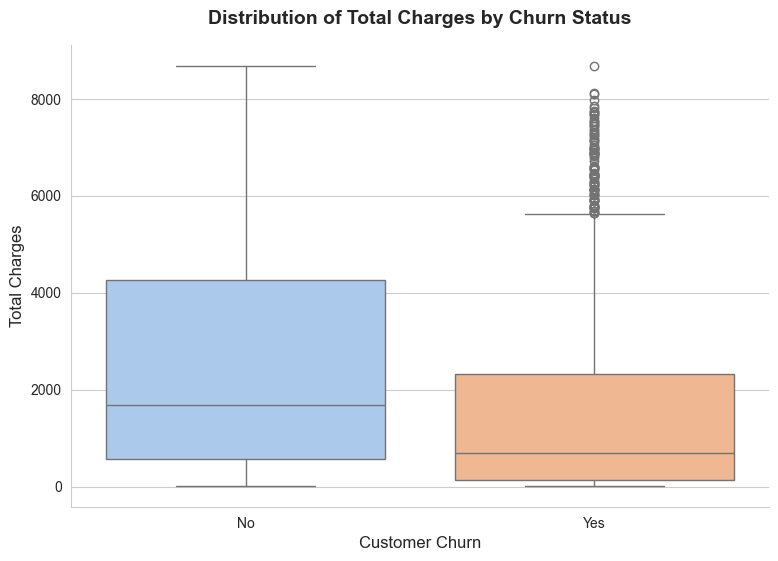

In [27]:
sns.set_style("whitegrid")
plt.figure(figsize=(9,6))
sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df,
    hue="Churn",
    palette="pastel",
    legend=False
)
plt.title('Distribution of Total Charges by Churn Status',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Churn', fontsize=12)
plt.ylabel('Total Charges', fontsize=12)
sns.despine()
plt.show()

### 7. Exploratory Data Analysis (EDA) - Total Charges vs. Churn

A bivariate boxplot was generated to inspect the distribution of `TotalCharges` across churn categories, reflecting the long-term financial impact of customer attrition.

#### Visual Insights & Mathematical Synthesis:

* **The Early Attrition Compression & Month-to-Month Churn:** The median `TotalCharges` for the churned group (`Yes`) is drastically compressed near the bottom (around $500). This confirms that a massive proportion of customers defect within their very first few months (e.g., months 1-3) without even reaching a 12-month milestone. This strongly points toward high volatility in non-contractual (month-to-month) subscribers or major onboarding friction.
* **High-Value Outlier Hemorrhage:** The long tail of upper outliers in the `Yes` group represents the worst-case financial scenario: loyal, high-spending customers (Total Charges > $6,000) who eventually abandoned the service. This emphasizes that late-stage churn, though less frequent, inflicts severe revenue damage.
* **The Retained Accumulation:** The `No` box plot displays a much healthier spread and higher median, proving that sustained customer tenure naturally drives compounding lifetime revenue for the organization.

In [35]:

from scipy import stats

# 1. Veriyi Churn olanlar ve olmayanlar olarak iki bağımsız gruba ayırıyoruz
charges_churn_yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
charges_churn_no = df[df['Churn'] == 'No']['MonthlyCharges']

# 2. Mann-Whitney U testini uyguluyoruz
stat, p_value = stats.mannwhitneyu(charges_churn_no, charges_churn_yes)

# 3. Sonucu mühendis gözüyle ekrana yazdırıyoruz
print(f"Test İstatistiği: {stat}")
print(f"P-Value (Olasılık Değeri): {p_value}")

if p_value < 0.05:
    print(" SONUÇ: Gruplar arasındaki fark rastlantısal DEĞİL! Aylık harcamalar Churn üzerinde doğrudan, anlamlı bir etkiye sahip.")
else:
    print(" SONUÇ: Fark istatistiksel olarak anlamsız, tamamen rastlantısal gürültü.")

Test İstatistiği: 3663498.5
P-Value (Olasılık Değeri): 8.46719504454875e-54
 SONUÇ: Gruplar arasındaki fark rastlantısal DEĞİL! Aylık harcamalar Churn üzerinde doğrudan, anlamlı bir etkiye sahip.


### 8. Statistical Hypothesis Testing (Validating Visual Insights)

To verify that the variance in `MonthlyCharges` between churned and retained customers is mathematically significant (and not a product of random noise), a **Mann-Whitney U Test** was performed.

* **Why Mann-Whitney U?** The distribution of `MonthlyCharges` is non-normal and bimodal (as proven by the KDE plot), making non-parametric testing the statistically robust choice over a standard Student's T-Test.
* **Hypothesis:** * $H_0$: There is no significant difference in monthly charges between churned and retained customers.
  * $H_1$: Churned customers pay significantly different (higher) monthly charges than retained customers.

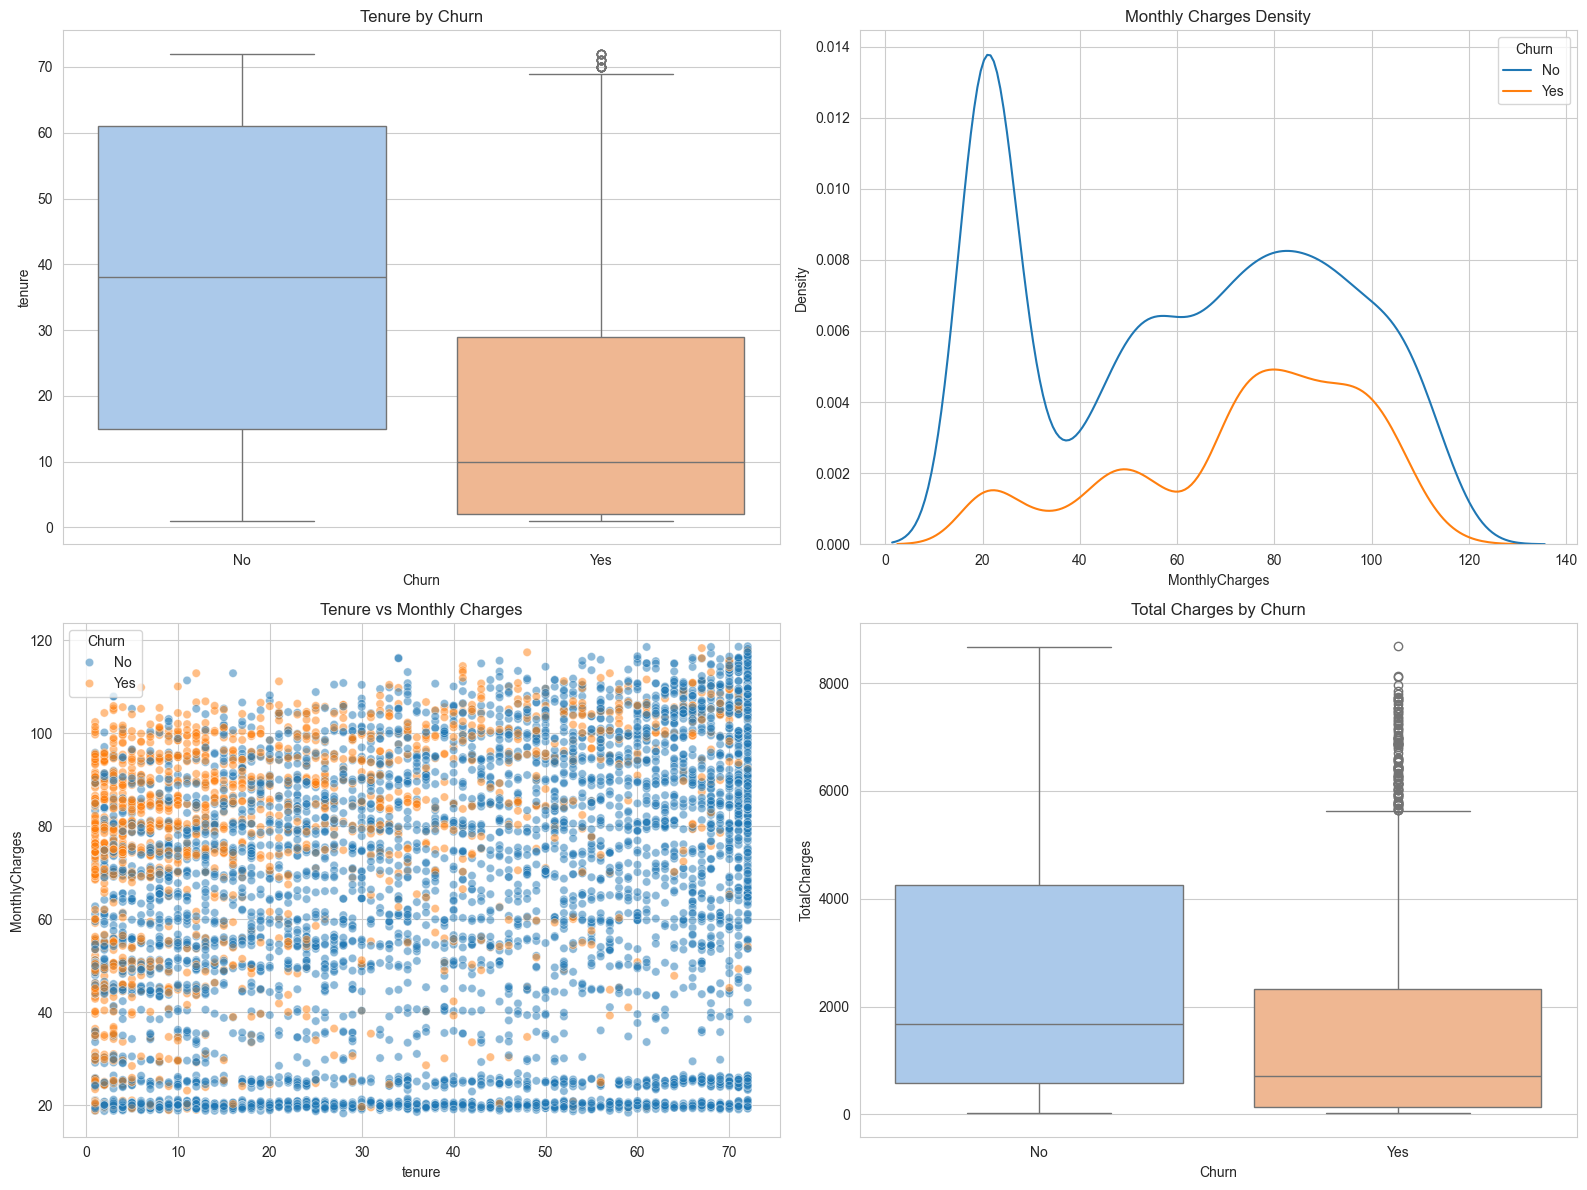

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Tenure Boxplot
sns.boxplot(x="Churn", y="tenure", data=df, hue='Churn', ax=axes[0,0], palette="pastel", legend=False)
axes[0,0].set_title("Tenure by Churn")

# 2. Monthly Charges KDE
sns.kdeplot(x="MonthlyCharges", hue="Churn", data=df, ax=axes[0,1])
axes[0,1].set_title("Monthly Charges Density")

# 3. Scatter Plot (Tenure vs Monthly Charges)
sns.scatterplot(x="tenure", y="MonthlyCharges", hue="Churn", data=df, alpha=0.5, ax=axes[1,0])
axes[1,0].set_title("Tenure vs Monthly Charges")

# 4. Total Charges Boxplot
sns.boxplot(x="Churn", y="TotalCharges", data=df,hue='Churn', ax=axes[1,1], palette="pastel", legend=False)
axes[1,1].set_title("Total Charges by Churn")

plt.tight_layout()
plt.show()

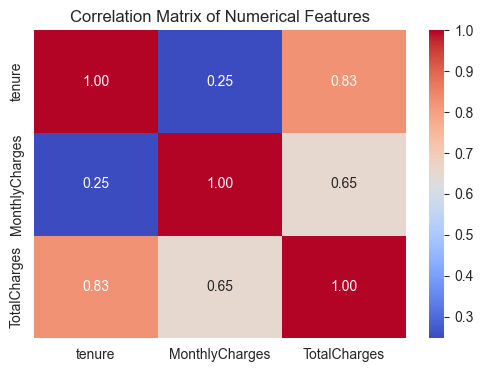

In [30]:
plt.figure(figsize=(6, 4))
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [1]:
df.to_csv('../data/Telco-Customer-Churn-Cleaned.csv', index=False)
print("Temizlenmiş veri kaydedildi!")

NameError: name 'df' is not defined